## Imports
---

In [2]:
import sys
sys.path.append("..")

import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from utils import StaticUtils

DATA_DIR = Path("../data/clean")
StaticUtils.set_plt_config()

## Data
---

In [3]:
df_ventas = pd.read_parquet(DATA_DIR / "ventas.parquet")
df_ventas.set_index("id_venta", inplace=True)

df_clientes = pd.read_parquet(DATA_DIR / "clientes.parquet")
df_clientes.set_index("id_cliente", inplace=True)

df_marketing = pd.read_parquet(DATA_DIR / "marketing.parquet")
df_marketing.set_index("id_campanha", inplace=True)

## Ventas y Marketing
---
### Feature Engineering

**Juntar `df_ventas` con `df_marketing`**

In [4]:
resumen_marketing = (
    df_marketing
    .groupby("producto")
    .agg(
        costo_total_campanhas=("costo", "sum"),
        inicio_campanha=("fecha_inicio", "min"),  # primer campaña
        fin_campanha=("fecha_fin", "max")         # última campaña
    )
    .reset_index()
)

ventas_marketing = (
    df_ventas
    .merge(resumen_marketing, on="producto", how="left")
)

**Calcular precio total (`precio` * `cantidad`)**

In [5]:
ventas_marketing["precio_total"] = (
    ventas_marketing["precio"] * ventas_marketing["cantidad"]
)

**Duración total de campañas en días**

In [6]:
ventas_marketing["duracion_campanha"] = (
    ventas_marketing["fin_campanha"] - ventas_marketing["inicio_campanha"]
).dt.days

**Día y mes de la venta**

In [7]:
ventas_marketing["dia_venta"] = ventas_marketing["fecha_venta"].dt.day_of_week
ventas_marketing["mes_venta"] = ventas_marketing["fecha_venta"].dt.month

**Día y mes de inicio y fin de campaña**

In [8]:
ventas_marketing["dia_inicio_campanha"] = ventas_marketing["inicio_campanha"].dt.day_of_week
ventas_marketing["mes_inicio_campanha"] = ventas_marketing["inicio_campanha"].dt.month
ventas_marketing["dia_fin_campanha"] = ventas_marketing["fin_campanha"].dt.day_of_week
ventas_marketing["mes_fin_campanha"] = ventas_marketing["fin_campanha"].dt.month

**Ratio ventas totales / costo de campañas**

In [9]:
ventas_marketing["ratio_ventas_costo"] = (
    ventas_marketing.groupby("producto")["precio_total"].transform("sum")
    / ventas_marketing["costo_total_campanhas"]
)

**Precio relativo:** el precio de cada producto dividido el precio promedio de su categoría. Un valor de 1.32 significa que ese producto cuesta 32% más que el promedio de su categoría; un valor de 0.40 significa que cuesta 60% menos.

In [10]:
ventas_marketing["precio_relativo"] = (
    ventas_marketing["precio"] / 
    ventas_marketing.groupby("categoria")["precio"].transform("mean")
)

**Nivel del precio:** si un producto es barato/muy barato o caro/muy caro; variable basada en el precio relativo calculado en la celda anterior. Condición definida:
* **0 - 0.7:**   Muy barato
* **0.7 - 0.9:**   Barato
* **0.9 - 1.0:**   Ligeramente barato
* **1.0 - 1.1:**   Ligeramente caro
* **1.1 - 1.3:**   Caro
* **Mayor a 1.3:** Muy caro

In [11]:
ventas_marketing["nivel_precio"] = pd.cut(
    ventas_marketing["precio_relativo"],
    bins=[0, 0.7, 0.9, 1.0, 1.1, 1.3, float("inf")],
    labels=["Muy barato", "Barato", "Ligeramente barato", "Ligeramente caro", "Caro", "Muy caro"]
)

Guardar y mostrar DataFrame

In [12]:
ventas_marketing.to_parquet(DATA_DIR / "ventas_marketing.parquet", index=False)
display(ventas_marketing.head())

,producto,precio,cantidad,fecha_venta,categoria,costo_total_campanhas,inicio_campanha,fin_campanha,precio_total,duracion_campanha,dia_venta,mes_venta,dia_inicio_campanha,mes_inicio_campanha,dia_fin_campanha,mes_fin_campanha,ratio_ventas_costo,precio_relativo,nivel_precio
0,Cuadro decorativo,69.94,5,2024-01-02,Decoración,15.85,2024-04-27,2024-12-23,349.70,240,1,1,5,4,0,12,3425.716088,0.943885,Ligeramente barato
1,Lámpara de mesa,105.10,5,2024-01-02,Decoración,15.93,2024-03-28,2024-10-07,525.50,193,1,1,3,3,0,10,5164.870056,1.418392,Muy caro
2,Secadora,97.96,3,2024-01-02,Electrodomésticos,14.59,2024-07-24,2025-01-07,293.88,167,1,1,2,7,1,1,3571.997944,1.280172,Caro
3,Heladera,114.35,8,2024-01-02,Electrodomésticos,13.11,2024-05-06,2024-08-09,914.80,95,1,1,0,5,4,8,1963.142639,1.494362,Muy caro
4,Secadora,106.21,4,2024-01-02,Electrodomésticos,14.59,2024-07-24,2025-01-07,424.84,167,1,1,2,7,1,1,3571.997944,1.387986,Muy caro


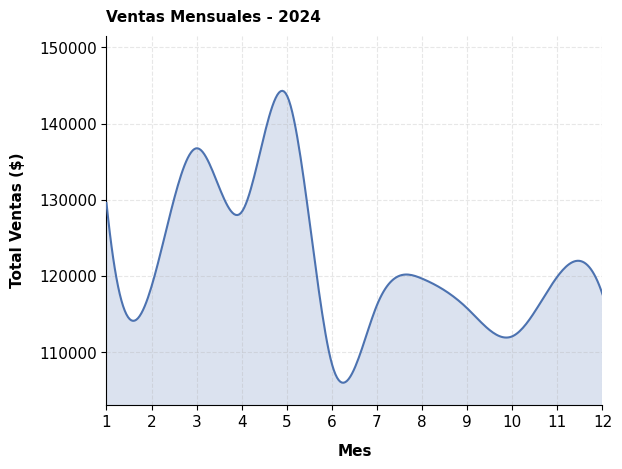

In [13]:
ventas_mensuales = (
    ventas_marketing
    .groupby("mes_venta")["precio_total"]
    .sum()
)

ventas_mensuales.index.name = "mes"
ventas_mensuales.name = "total_ventas"

x_smooth, y_smooth = (
    StaticUtils.smooth_line(
        x = ventas_mensuales.index, 
        y = ventas_mensuales.values
    )
)

plt.plot(x_smooth, y_smooth, zorder=3)
plt.fill_between(x_smooth, y_smooth, alpha=0.2)
plt.xticks(ventas_mensuales.index)
plt.xlim(x_smooth.min(), x_smooth.max())
plt.ylim(bottom=ventas_mensuales.min() * 0.95)
plt.title("Ventas Mensuales - 2024", loc="left")
plt.xlabel("Mes")
plt.ylabel("Total Ventas ($)")
plt.show()

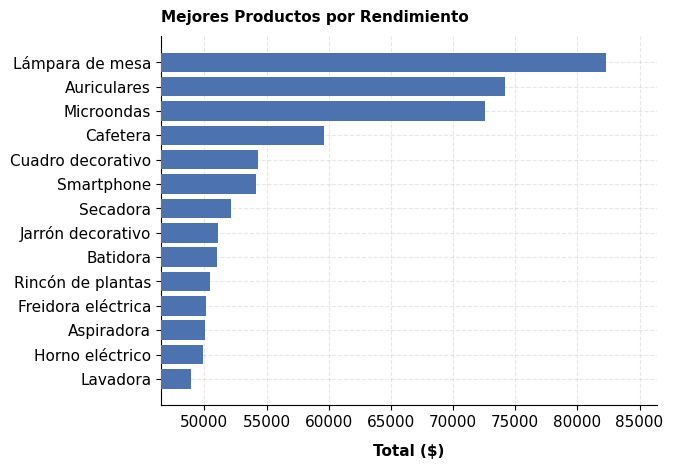

In [14]:
mejor_rendimiento = (
    ventas_marketing
    .groupby("producto")["precio_total"]
    .sum()
    .pipe(lambda s: s[s > s.mean()])
    .sort_values(ascending=True)
)

plt.barh(mejor_rendimiento.index, mejor_rendimiento.values, zorder=3)
plt.xlim(left=mejor_rendimiento.min() * 0.95)
plt.title("Mejores Productos por Rendimiento", loc="left")
plt.xlabel("Total ($)")
plt.ylabel("")
plt.show()

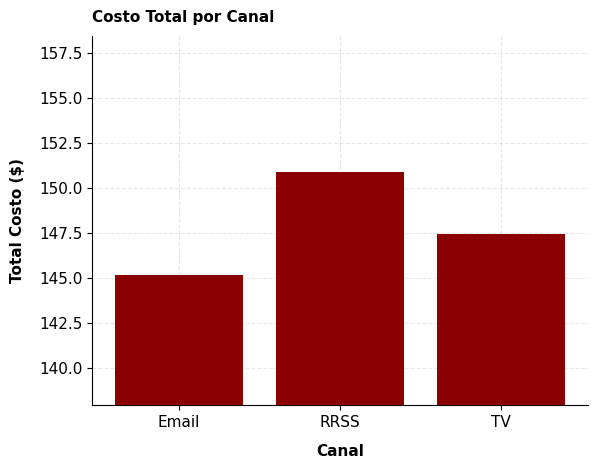

In [15]:
costo_total_por_canal = (
    df_marketing
    .reset_index()
    .groupby("canal")["costo"]
    .sum()
)

plt.bar(
    costo_total_por_canal.index, 
    costo_total_por_canal.values, 
    zorder=3, color="darkred"
)

plt.ylim(bottom=costo_total_por_canal.min() * 0.95)
plt.title("Costo Total por Canal", loc="left")
plt.xlabel("Canal")
plt.ylabel("Total Costo ($)")
plt.show()

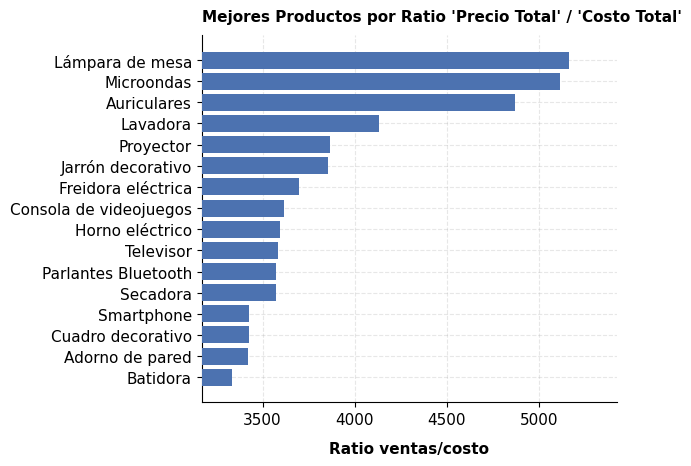

In [16]:
ratio_ordenado = (
    ventas_marketing
    .drop_duplicates(subset=["producto"])
    .set_index("producto")["ratio_ventas_costo"]
    .pipe(lambda s: s[s > s.mean()])
    .sort_values(ascending=True)
)

plt.barh(ratio_ordenado.index, ratio_ordenado.values, zorder=3)
plt.xlim(left=ratio_ordenado.min() * 0.95)
plt.title("Mejores Productos por Ratio 'Precio Total' / 'Costo Total'", loc="left")
plt.xlabel("Ratio ventas/costo")
plt.ylabel("")
plt.tight_layout()
plt.show()

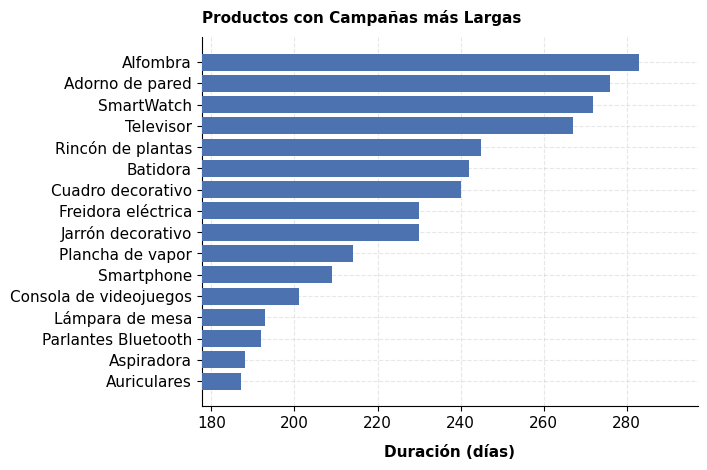

In [17]:
campanhas_mas_largas = (
    ventas_marketing
    [["producto", "duracion_campanha"]]
    .set_index("producto")
    .pipe(lambda df: df[df["duracion_campanha"] > df["duracion_campanha"].mean()])
    .sort_values("duracion_campanha", ascending=True)
)

plt.barh(campanhas_mas_largas.index, campanhas_mas_largas["duracion_campanha"], zorder=3)
plt.xlim(left=campanhas_mas_largas["duracion_campanha"].min() * 0.95)
plt.title("Productos con Campañas más Largas", loc="left")
plt.xlabel("Duración (días)")
plt.show()

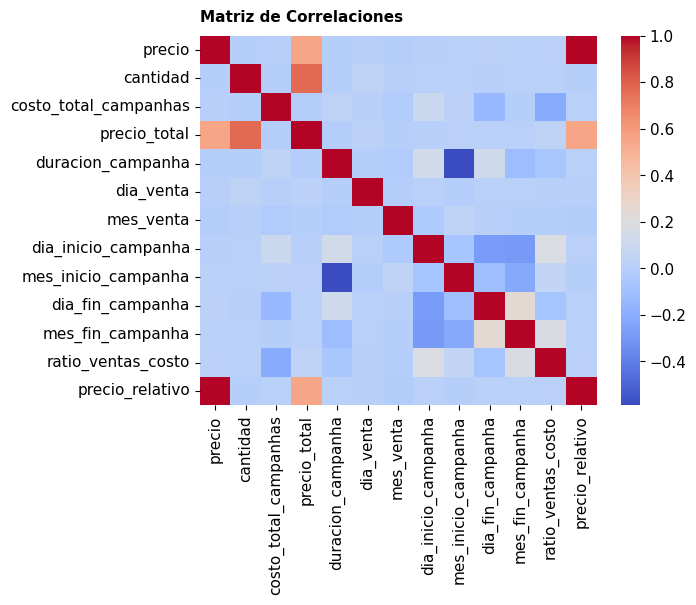

In [18]:
corr = ventas_marketing.select_dtypes(include="number").corr()
sns.heatmap(corr, cmap="coolwarm")
plt.title("Matriz de Correlaciones", loc="left")
plt.grid(False)
plt.show()

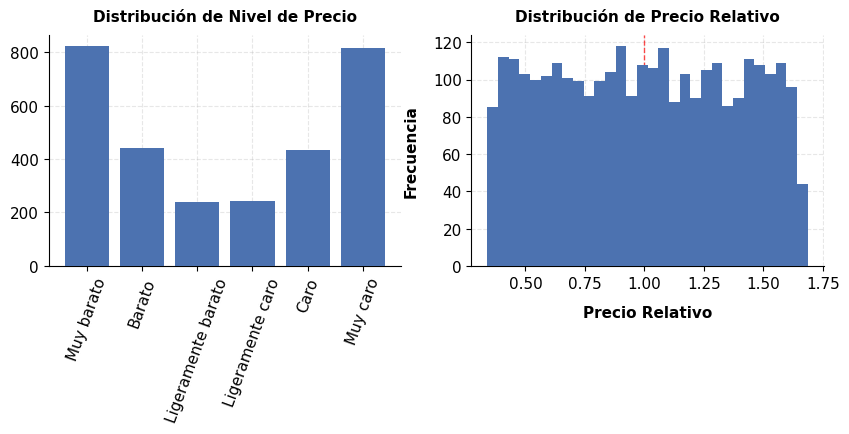

In [33]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))

# Distribución de Nivel de Precio
orden = ["Muy barato", "Barato", "Ligeramente barato", "Ligeramente caro", "Caro", "Muy caro"]
conteo = ventas_marketing["nivel_precio"].value_counts().reindex(orden)
ax1.bar(conteo.index, conteo.values, zorder=3)
ax1.set_title("Distribución de Nivel de Precio")
ax1.tick_params(axis="x", rotation=70)

# Distribución de Precio Relativo
ax2.hist(ventas_marketing["precio_relativo"], bins=30, zorder=3)
ax2.axvline(1.0, color="red", linestyle="--", alpha=0.7, linewidth=1)
ax2.set_title("Distribución de Precio Relativo")
ax2.set_xlabel("Precio Relativo")
ax2.set_ylabel("Frecuencia")

plt.show()

## Clientes
---

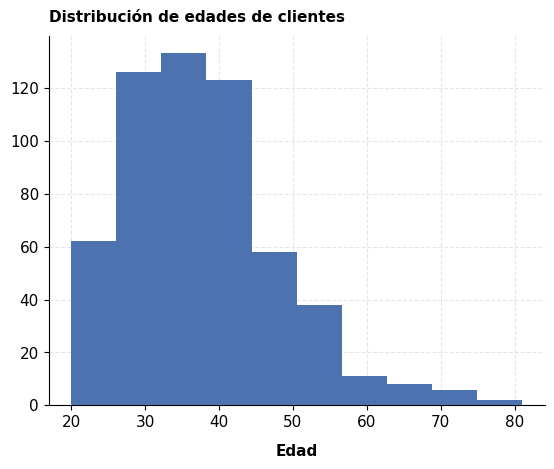

In [20]:
plt.hist(df_clientes["edad"], zorder=3)
plt.title("Distribución de edades de clientes", loc="left")
plt.xlabel("Edad")
plt.show()

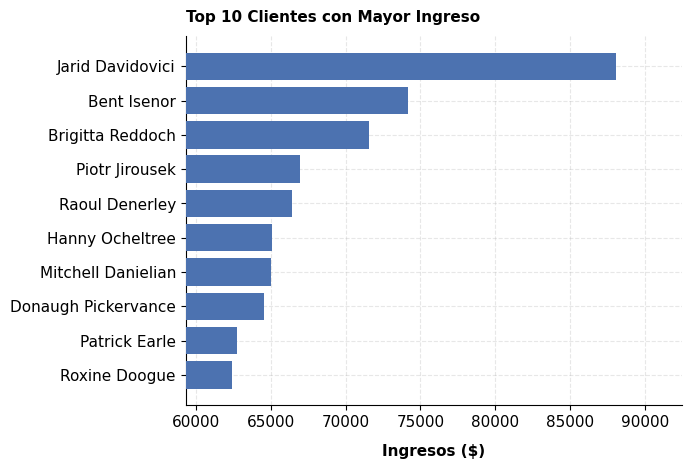

In [21]:
top10 = df_clientes.nlargest(10, columns="ingresos")
top10 = top10.sort_values(ascending=True, by="ingresos")
plt.barh(top10["nombre"], top10["ingresos"], zorder=3)
plt.xlim(left=top10["ingresos"].min() * 0.95)
plt.title("Top 10 Clientes con Mayor Ingreso", loc="left")
plt.xlabel("Ingresos ($)")
plt.show()

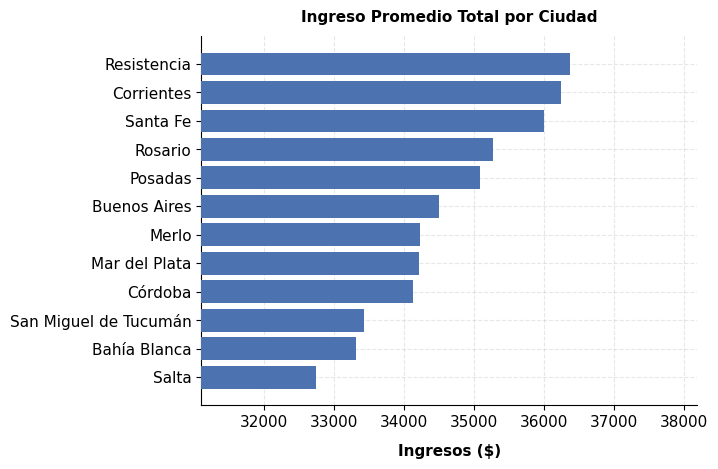

In [22]:
ingresos_por_ciudad = (
    df_clientes
    .groupby("ciudad")["ingresos"]
    .mean()
    .sort_values(ascending=True)
)

plt.barh(ingresos_por_ciudad.index, ingresos_por_ciudad.values, zorder=3)
plt.xlim(left=ingresos_por_ciudad.values.min() * 0.95)
plt.title("Ingreso Promedio Total por Ciudad")
plt.xlabel("Ingresos ($)")
plt.show()

## Conclusiones
---

### **Ventas y Marketing**

**1. Ventas mensuales.** El pico máximo de ventas se registra en mayo (alrededor de 144.000), seguido de una caída pronunciada hacia junio, que representa el mínimo del año (menos de $110.000). Se observan dos picos secundarios en marzo y enero. A partir de julio las ventas se estabilizan en un rango más bajo (110.000 a 122.000) respecto a la primera mitad del año, sin recuperar los niveles del primer semestre.

**2. Costos por canal de campaña.** Los tres canales presentan costos totales muy similares, con diferencias menores entre sí. RRSS es el canal más costoso (150 a 152.5), seguido por TV (147) y Email (145). La poca diferencia entre canales sugiere una inversión en marketing relativamente equilibrada, sin una apuesta clara por ninguno en particular.

**3. Mejores productos por rendimiento (umbral basado en la media).** Las lámparas de mesa lideran el ranking (con ganancias totales de más de 80.000) seguidas de los auriculares, y tercero los microondas. Si añadimos a la ecuación la variable de costo total por campañas (ratio ventas/costo), los microondas ocupan el lugar de los auriculares. De aquí para abajo, el resto de productos varían entre la ganancia total, y la ganancia total con el costo de campañas añadido.

**4. Productos con las campañas más largas.** Alfombra lidera con más de 280 días de campaña activa, seguida por Adorno de pared (alrededor de 275 días) y SmartWatch (cerca de 270 días). Todos los productos del top 4 superan los 265 días, mientras que el resto del grupo se concentra entre 180 y 240 días. Vale aclarar que la duración refleja el período entre la primera y última campaña del producto, no necesariamente que haya habido publicidad activa durante todo ese tiempo.

**5. Distribución de precio relativo.** El precio relativo de las transacciones se distribuye de forma uniforme a lo largo de todo el rango, sin concentraciones significativas en ningún valor particular. Los extremos "Muy barato" y "Muy caro" concentran la mayor cantidad de transacciones (alrededor de 820 cada uno), mientras que los rangos intermedios tienen menor frecuencia. Esto sugiere que los clientes no muestran una preferencia clara por productos en un rango de precio particular dentro de su categoría.

**6. Correlaciones.** La matriz confirma que `precio_total` tiene correlación fuerte con `precio` (0.56) y `cantidad` (0.77), lo que era esperado dado que es una variable calculada a partir de ambas. El resto de las variables presentan correlaciones cercanas a cero entre sí, lo que indica que no hay relaciones lineales significativas en el dataset.

### **Clientes**

**1. Distribución de edades.** La distribución es asimétrica hacia la derecha, con la mayor concentración de clientes entre los 25 y 45 años. A partir de los 45 la frecuencia cae progresivamente, con muy pocos clientes mayores de 65 años. Esto sugiere que los productos apuntan a un público adulto joven, o bien que los canales de captación de clientes tienen menor alcance en personas mayores.

**2. Clientes con mayores ingresos.** Jarid Davidovici lidera con ingresos cercanos a $88.000, superando ampliamente al segundo lugar, Bent Isenor (cerca de 74.000), y al tercero, Brigitta Reddoch (cerca de 71.000). El resto del top 10 se agrupa entre 63.000 y 67.000, con diferencias menores entre ellos. Estos valores fueron identificados como outliers altos durante la limpieza y se decidió conservarlos por considerarlos posibles, aunque no puede descartarse que sean errores de carga.

**3. Ingreso promedio por ciudad.** Lo más llamativo es que las diferencias entre ciudades son relativamente pequeñas, todas se concentran entre 32.000 y 37.000, lo que sugiere una distribución bastante homogénea de ingresos en el dataset. Resistencia, Corrientes y Santa Fe lideran el promedio, lo que es contraintuitivo ya que son ciudades del Nordeste Argentino que en la realidad suelen tener indicadores económicos más bajos que Buenos Aires o Córdoba. Esto puede indicar que la muestra de clientes no es representativa de la población general; probablemente son clientes con cierto poder adquisitivo necesario para comprar los productos del catálogo.